In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

DATASET_PATH = PROJECT_PATH / "datasets" / "raw" / "UAH-DRIVESET-v1"

print(DATASET_PATH)

/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path

dataset_path = Path("/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1")

print(dataset_path.exists())

True


In [5]:
video_paths = list(dataset_path.rglob("*.mp4"))

print("MP4 sayısı:", len(video_paths))

MP4 sayısı: 40


In [6]:
drivers = list(dataset_path.iterdir())

print(len(drivers))

for d in drivers[:5]:
    print(d)

9
/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1/D1
/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1/D2
/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1/D3
/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1/D4
/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1/D5


In [7]:
video_path = video_paths[0]

print(video_path)

/content/drive/MyDrive/UAH_Project/datasets/raw/UAH-DRIVESET-v1/D1/20151111125233-24km-D1-AGGRESSIVE-MOTORWAY/20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.mp4


In [8]:
cap = cv2.VideoCapture(str(video_path))

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print(f"FPS         : {fps}")
print(f"Frames      : {frame_count}")
print(f"Duration    : {duration:.2f} sec")
print(f"Resolution  : {width} x {height}")

cap.release()

FPS         : 29.973079213817748
Frames      : 23548
Duration    : 785.64 sec
Resolution  : 960 x 540


In [9]:
cap = cv2.VideoCapture(str(video_path))

frames = []

for _ in range(5):

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frames.append(frame)

cap.release()

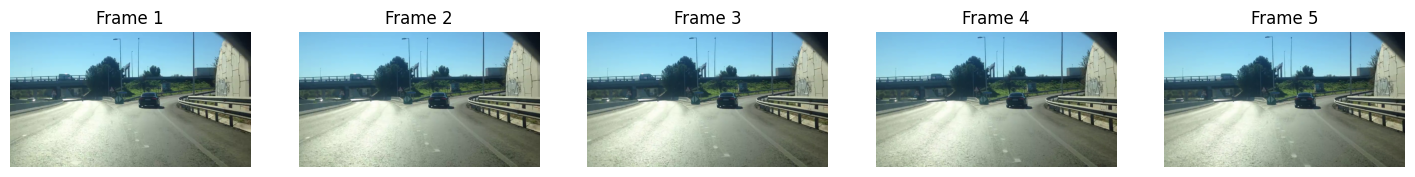

In [10]:
plt.figure(figsize=(18,4))

for i, frame in enumerate(frames):

    plt.subplot(1, len(frames), i+1)

    plt.imshow(frame)

    plt.title(f"Frame {i+1}")

    plt.axis("off")

plt.show()

In [11]:
cap = cv2.VideoCapture(str(video_path))

fps = int(cap.get(cv2.CAP_PROP_FPS))

frames = []

for second in range(5):

    cap.set(cv2.CAP_PROP_POS_FRAMES, second * fps)

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frames.append(frame)

cap.release()

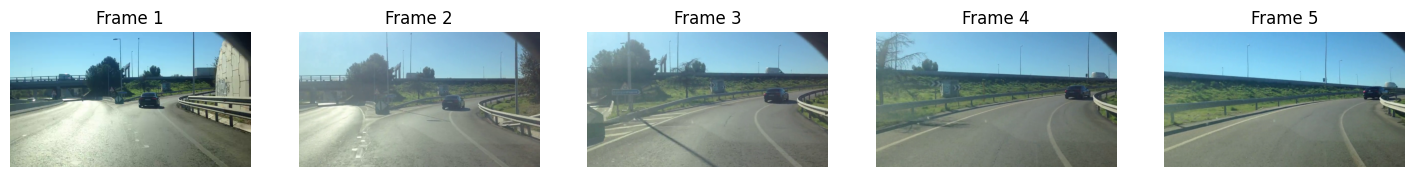

In [12]:
plt.figure(figsize=(18,4))

for i, frame in enumerate(frames):

    plt.subplot(1, len(frames), i+1)

    plt.imshow(frame)

    plt.title(f"Frame {i+1}")

    plt.axis("off")

plt.show()

In [13]:
import torch
import torchvision.models as models
from torchvision.models import ResNet50_Weights

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = ResNet50_Weights.DEFAULT

resnet = models.resnet50(
    weights=weights,
)

print(resnet)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [14]:
feature_extractor = torch.nn.Sequential(
    *list(resnet.children())[:-1]
)

feature_extractor = feature_extractor.to(device)

feature_extractor.eval()

print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [15]:
from torchvision import transforms

transform = weights.transforms()

print(transform)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


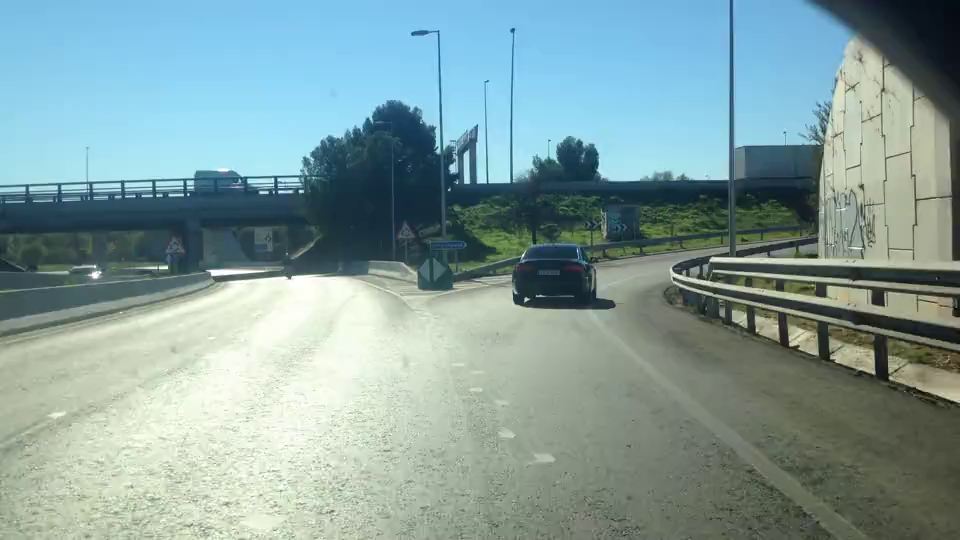

In [16]:
from PIL import Image

image = Image.fromarray(frames[0])

image

In [17]:
input_tensor = transform(image)

print(input_tensor.shape)

torch.Size([3, 224, 224])


In [18]:
input_tensor = input_tensor.unsqueeze(0).to(device)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [19]:
with torch.no_grad():

    feature = feature_extractor(input_tensor)

print(feature.shape)

torch.Size([1, 2048, 1, 1])


In [20]:
feature = feature.squeeze()

print(feature.shape)

torch.Size([2048])


In [21]:
print(feature[:20])

tensor([0.0264, 0.0304, 0.2206, 0.0000, 0.2327, 0.0000, 0.1955, 0.0389, 0.0252,
        0.0507, 0.0677, 0.0000, 0.0251, 0.0000, 0.0342, 0.3154, 0.0000, 0.1031,
        0.0000, 0.0314], device='cuda:0')


In [22]:
from PIL import Image
import torch
import cv2
import numpy as np

def extract_video_feature(
    video_path,
    feature_extractor,
    transform,
    device,
    sample_interval=1,
):
    """
    Extract one 2048-dimensional feature vector from a video.

    sample_interval:
        seconds between sampled frames.
    """

    cap = cv2.VideoCapture(str(video_path))

    fps = int(cap.get(cv2.CAP_PROP_FPS))

    features = []

    second = 0

    while True:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            second * fps,
        )

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB,
        )

        image = Image.fromarray(frame)

        input_tensor = transform(image)

        input_tensor = input_tensor.unsqueeze(0).to(device)

        with torch.no_grad():

            feature = feature_extractor(input_tensor)

        feature = feature.squeeze().cpu().numpy()

        features.append(feature)

        second += sample_interval

    cap.release()

    features = np.stack(features)

    video_feature = features.mean(axis=0)

    return video_feature

In [23]:
video_feature = extract_video_feature(
    video_path,
    feature_extractor,
    transform,
    device,
)

print(video_feature.shape)

(2048,)


In [24]:
print(video_feature[:20])

[0.02594483 0.01876143 0.05952455 0.00176804 0.09878605 0.00388028
 0.01763651 0.02283511 0.02213765 0.01021624 0.02292679 0.005899
 0.05349796 0.00706995 0.00958523 0.4209218  0.02939485 0.07388218
 0.0045681  0.01727032]


In [25]:
all_features = []
all_labels = []
all_video_names = []

for video_path in video_paths:

    feature = extract_video_feature(
        video_path,
        feature_extractor,
        transform,
        device,
    )

    all_features.append(feature)

    all_video_names.append(video_path.name)

print(len(all_features))

40


In [26]:
X_video = np.stack(all_features)

print(X_video.shape)

(40, 2048)


In [27]:
def extract_label(video_name):

    if "AGGRESSIVE" in video_name:
        return 1

    elif "DROWSY" in video_name:
        return 2

    return 0

In [28]:
y_video = np.array(
    [
        extract_label(name)
        for name in all_video_names
    ]
)

print(y_video)
print(y_video.shape)

[1 2 0 1 0 2 0 0 2 0 2 1 1 0 1 0 2 1 0 0 2 2 0 1 0 2 1 0 1 2 0 0 0 1 2 2 2
 1 0 0]
(40,)


In [29]:
save_path = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "resnet50_features.npz"
)

np.savez_compressed(
    save_path,
    X=X_video,
    y=y_video,
    video_names=all_video_names,
)

print(f"Saved to: {save_path}")

Saved to: /content/drive/MyDrive/UAH_Project/datasets/processed/resnet50_features.npz
